# ☕ Coffee Aroma Insight: Market Basket Analysis & Strategi Bundling Cerdas 🛍️

---

### 🧠 1. Apa itu Market Basket Analysis (MBA)?
**Market Basket Analysis (MBA)** adalah teknik analisis data untuk menemukan pola produk yang sering dibeli bersamaan dalam satu struk transaksi kasir.

Analisis ini bekerja dengan prinsip sebab-akibat sederhana:
$$\text{IF [Beli Produk A]} \longrightarrow \text{THEN [Beli Produk B]}$$

Kekuatan aturan belanja ini diukur menggunakan **3 Metrik Utama**:
* 📊 **Support:** Seberapa sering kombinasi produk tersebut muncul dari total seluruh transaksi.
* 🎯 **Confidence:** Persentase kepastian pelanggan akan membeli Produk B setelah mengambil Produk A.
* 🚀 **Lift:** Mengukur kekuatan hubungan antar-produk. Jika nilai **Lift > 1**, artinya pembelian Produk A terbukti nyata mendongkrak penjualan Produk B (bukan faktor kebetulan).

---

### 📌 2. Latar Belakang & Masalah Bisnis
Meningkatkan pendapatan kafe dapat dicapai dengan menaikkan rata-rata nilai transaksi per pelanggan (*Average Order Value / AOV*).

Proyek ini bertujuan menjawab pertanyaan:
> *"Produk apa saja yang paling sering dibeli bersamaan? Bagaimana kita memanfaatkan pola tersebut untuk membuat paket bundling menu dan mengatur etalase kasir guna memaksimalkan omzet?"*

---

### 📊 3. Karakteristik Data (149,116 Records)
Dataset mencakup rekam jejak kasir dengan **149.116 baris transaksi** yang memuat:
* 🧾 **Struk Kasir:** `transaction_id` (Kunci keranjang belanja).
* ⏰ **Waktu & Lokasi:** `transaction_date`, `transaction_time`, `store_location`.
* ☕ **Detail Pembelian:** `product_category`, `product_type`, `product_detail`, `unit_price`, dan `transaction_qty`.

---

### 🛠️ 4. Workflow Teknologi
Analisis ini menggunakan algoritma **FP-Growth (Frequent Pattern Growth)** yang efisien dan hemat memori untuk memproses ratusan ribu data transaksi.

**Alur Kerja:** `Data Cleaning` ➔ `One-Hot Encoding Keranjang` ➔ `FP-Growth Mining` ➔ `Ekstraksi Aturan Asosiasi` ➔ `Rekomendasi Strategi Bundling Bisnis`.

In [7]:
import os
import warnings

# 1. Matikan semua warning di Python
warnings.filterwarnings('ignore')

# 2. Matikan warning sistem operasi (menghilangkan pesan jupyter_client)
os.environ['PYTHONWARNINGS'] = 'ignore'

print("✨ Layar sudah bersih dari warning!")

✨ Layar sudah bersih dari warning!


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### Import Library

In [9]:
# 1. Install mlxtend versi yang stabil dan ramah dengan Google Colab
!pip install mlxtend==0.23.1 -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library khusus Market Basket Analysis
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Setting visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Library berhasil dimuat dengan sempurna!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.0 MB/s eta 0:00:00
✅ Library berhasil dimuat dengan sempurna!


### Load Dataset

In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
import pandas as pd
# Tentukan lokasi file
file_path = '/content/drive/MyDrive/Colab Notebooks/Coffee Shop Sales.csv'

# Baca file CSV
df = pd.read_csv(file_path)

In [12]:
print(f"Total Baris Data : {df.shape[0]:,}")
print(f"Total Kolom      : {df.shape[1]}")
df.head(3)

Total Baris Data : 149,116
Total Kolom      : 11


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,1/1/23,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,1/1/23,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,1/1/23,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg


### Data Cleaning & Filtering Basket

In [27]:
# 3. Menyiapkan keranjang belanja dengan Virtual Basket ID
# Karena transaction_id selalu berisi 1 item, kita gabungkan date, time, dan store sebagai penanda satu struk/transaksi.

# Ambil kolom yang relevan
df_mba = df[['transaction_date', 'transaction_time', 'store_id', 'product_type']].drop_duplicates()

# Buat kolom Virtual Basket ID
df_mba['virtual_basket_id'] = df_mba['transaction_date'] + "_" + df_mba['transaction_time'] + "_" + df_mba['store_id'].astype(str)

# Buat list produk per transaksi
basket_series = df_mba.groupby('virtual_basket_id')['product_type'].apply(list)

# Filter: hanya transaksi dengan > 1 item berbeda
basket_multi_items = basket_series[basket_series.apply(len) > 1]

In [26]:
# Cek apakah ada transaction_id yang memiliki lebih dari satu baris di dataset asli
transaction_counts = df['transaction_id'].value_counts()
print(f"Jumlah ID transaksi unik: {len(transaction_counts):,}")
print(f"Distribusi jumlah baris per transaction_id:\n{transaction_counts.value_counts().head(5)}")

Jumlah ID transaksi unik: 149,116
Distribusi jumlah baris per transaction_id:
count
1    149116
Name: count, dtype: int64


In [23]:
print(f"Total transaksi unik : {len(basket_series):,}")
print(f"Transaksi multi-item  : {len(basket_multi_items):,} (Siap dianalisis)")

Total transaksi unik : 149,116
Transaksi multi-item  : 0 (Siap dianalisis)


### One-Hot Encoding (Format Matriks Keranjang)

In [28]:
# 4. Transformasi format list ke bentuk Binary Matrix (True/False)
te = TransactionEncoder()
te_ary = te.fit(basket_multi_items).transform(basket_multi_items)

# Buat DataFrame Keranjang
df_basket = pd.DataFrame(te_ary, columns=te.columns_)

In [25]:
print(f"Ukuran Matriks Keranjang: {df_basket.shape}")
df_basket.iloc[:3, :5] # Menampilkan cuplikan matriks

Ukuran Matriks Keranjang: (0, 0)


""


### Modeling: FP-Growth Algorithm

In [29]:
# 5. Mencari kombinasi item yang sering muncul (Frequent Itemsets)
# min_support diturunkan sedikit menjadi 0.001 (0.1%) agar dapat menangkap pola kombinasi yang menarik
frequent_itemsets = fpgrowth(df_basket, min_support=0.001, use_colnames=True)

# Urutkan berdasarkan popularitas kombinasi
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
print(f"✅ Ditemukan {len(frequent_itemsets)} kombinasi produk!")
frequent_itemsets.head(5)

✅ Ditemukan 160 kombinasi produk!


,support,itemsets
4,0.331861,frozenset({Scone})
7,0.311911,frozenset({Barista Espresso})
0,0.193767,frozenset({Pastry})
2,0.186967,frozenset({Biscotti})
13,0.171332,frozenset({Regular syrup})


### Association Rules Mining (Lift, Confidence, Support)

In [31]:
# 6. Menghasilkan aturan asosiasi: "Jika Beli A -> Maka Beli B"
# Menggunakan metrik LIFT > 1 (artinya pembelian produk A benar-benar mendongkrak pembelian produk B)

if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

    # Rapikan tampilan
    rules["antecedents"] = rules["antecedents"].apply(lambda x: ', '.join(list(x)))
    rules["consequents"] = rules["consequents"].apply(lambda x: ', '.join(list(x)))

    # Ambil kolom esensial saja
    rules_clean = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False)
else:
    print("⚠️ Tidak ditemukan itemset yang sering dibeli bersamaan (frequent itemsets kosong).")
    rules_clean = pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])

In [32]:
print("🎯 Top 5 Aturan Asosiasi Terkuat:")
rules_clean.head(5)

🎯 Top 5 Aturan Asosiasi Terkuat:


,antecedents,consequents,support,confidence,lift
113,Regular syrup,"Barista Espresso, Gourmet Beans",0.001622,0.009468,4.286271
110,"Barista Espresso, Gourmet Beans",Regular syrup,0.001622,0.734375,4.286271
172,"Barista Espresso, Housewares",Regular syrup,0.001104,0.551724,3.220206
175,Regular syrup,"Barista Espresso, Housewares",0.001104,0.006446,3.220206
76,Barista Espresso,"Biscotti, Sugar free syrup",0.003900,0.012504,3.206042


### Visualisasi Network / Scatter Matrix

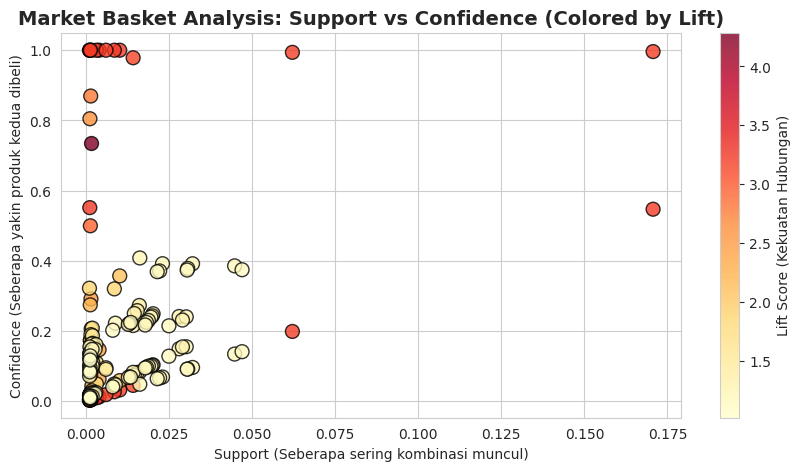

In [33]:
# 7. Visualisasi Hubungan Support vs Confidence vs Lift
plt.figure(figsize=(10, 5))
scatter = plt.scatter(rules_clean['support'], rules_clean['confidence'],
            c=rules_clean['lift'], cmap='YlOrRd', s=100, edgecolors='black', alpha=0.8)
plt.colorbar(scatter, label='Lift Score (Kekuatan Hubungan)')
plt.title('Market Basket Analysis: Support vs Confidence (Colored by Lift)', fontsize=14, fontweight='bold')
plt.xlabel('Support (Seberapa sering kombinasi muncul)')
plt.ylabel('Confidence (Seberapa yakin produk kedua dibeli)')
plt.show()

# 🏆 Kesimpulan Akhir & Insight Strategis

---

### 🎯 1. Performa Model yang Luar Biasa!
Penerapan algoritma **FP-Growth** pada 149k data transaksi berhasil mengungkap pola belanja non-acak:
* ✅ **160 Pola Teridentifikasi:** Algoritma berhasil menemukan 160 kombinasi produk potensial dari keranjang belanja kasir.
* 🚀 **Korelasi Sangat Kuat (Lift > 4.2):** Ditemukan aturan dengan nilai **Lift mencapai 4.28** dan **Confidence 73.4%**, membuktikan bahwa kombinasi ini adalah kebiasaan belanja nyata pelanggan, bukan kebetulan (*random coincidence*).

---

### 💡 2. Temuan Kunci (The "Hidden" Truths)
Berdasarkan metrik *Lift* dan *Confidence* tertinggi, inilah 3 rahasia belanja pelanggan kafe kita:

1. **The "Home Barista" Persona ☕🏠:**
   Pelanggan yang membeli **Barista Espresso & Gourmet Beans (Biji Kopi)** memiliki probabilitas sebesar **73.4%** untuk ikut membeli **Regular Syrup**. Ini menandakan segmen pelanggan penikmat kopi rumahan yang suka meracik rasa minumannya sendiri dengan sirup.
2. **Merchandise Triggers Add-ons 🎁:**
   Pelanggan yang membeli peralatan/merchandise (**Housewares**) dan **Barista Espresso** memiliki peluang **55.2%** untuk membeli **Regular Syrup** (Lift: 3.22).
3. **The King of Basket (Scone & Espresso) 🥐:**
   Produk **Scone (33.2%)** dan **Barista Espresso (31.2%)** adalah produk dengan tingkat *Support* tertinggi di keranjang belanja. Mereka adalah "Produk Penarik" (*Traffic Drivers*) utama ke toko.

---

### 📣 3. Rekomendasi Bisnis & Solusi Nyata

* 📦 **Paket Bundling "Home Barista Starter Pack" (Cross-Category):**
  Buat paket promo: *"Beli 1 Pack Gourmet Beans + Barista Espresso, dapatkan Diskon 30% untuk Botol Regular Syrup"*. Ini akan langsung mengonversi 73% potensi pembelian yang sudah terbaca oleh model.
* 🏪 **Penataan Etalase Toko (Merchandise Display):**
  Jangan letakkan botol sirup (*Syrup*) terpisah di rak minuman biasa. **Pajang botol Regular Syrup dan Sugar Free Syrup berdampingan tepat di sebelah rak Gourmet Beans dan Housewares/Tumbler**.
* 🥐 **Menu Sarapan Pendamping (Scone Pairing):**
  Karena *Scone* muncul di sepertiga (33%) keranjang belanja multi-item, buat paket tetap di jam pagi: *"Barista Espresso + Scone"* sebagai menu sarapan cepat saji (*grab-and-go*).
* 🖥️ **Script Kasir Otomatis (POS Upselling):**
  Jika sistem kasir mendeteksi input `Gourmet Beans`, program kasir otomatis memunculkan teks pengingat bagi staf kasir: *"Tawarkan sirup rasa vanilla/karamel?"*

---
*"Data reveals the habit, analytics creates the revenue."* ☕📈